# spare parts demand forecasting for inventory optimization

client: NewX services )    (
Domein: inventory maagement )   (
Project Code: PRCL-0027

In [1]:
#import requered libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [3]:
#load the datasets
df = pd.read_csv("C:/Users/valak/Favorites/Downloads/client project/service_data.csv")
df.head()

,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text
0,30-05-17,30-05-17,shivXXXXXXXXXX,KA03MFXXXX,BAJAJ AVENGER STREET 220,50000,ENGINE OIL
1,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,ENGINE OIL
2,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,POLISH
3,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,CONSUMABLES
4,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,COOLANT OIL


### understand dataset structure

In [5]:
df.shape

(28482, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28482 entries, 0 to 28481
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   invoice_date           28482 non-null  object
 1   job_card_date          28482 non-null  object
 2   business_partner_name  28482 non-null  object
 3   vehicle_no             28482 non-null  object
 4   vehicle_model          28482 non-null  object
 5   current_km_reading     28482 non-null  int64 
 6   invoice_line_text      28448 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.5+ MB


In [7]:
df.describe(include="all")

,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text
count,28482,28482,28482,28482,28482,28482.000000,28448
unique,555,553,1010,846,28,NaN,502
top,01-12-18,01-12-18,venkXXXXXXXXXX,KA53EVXXXX,BAJAJ PULSAR 150,NaN,ENGINE OIL
freq,179,179,424,1313,8633,NaN,3802
mean,NaN,NaN,NaN,NaN,NaN,19348.003827,NaN
std,NaN,NaN,NaN,NaN,NaN,25246.722306,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,3988.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,12420.500000,NaN
75%,NaN,NaN,NaN,NaN,NaN,27905.000000,NaN


##### The dataset contains service center transaction records including invoice dates, job card dates, vehicle details, mileage readings, and spare part descriptions. This data will be used to analyze historical spare parts usage patterns and to forecast future demand for inventory optimization

## data cleanig & preprocessing

In [9]:
#convert data columns 
df['invoice_date'] = pd.to_datetime(df['invoice_date'])
df['job_card_date'] = pd.to_datetime(df['job_card_date'])

C:\Users\valak\AppData\Local\Temp\ipykernel_12536\3226102439.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['invoice_date'] = pd.to_datetime(df['invoice_date'])
C:\Users\valak\AppData\Local\Temp\ipykernel_12536\3226102439.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['job_card_date'] = pd.to_datetime(df['job_card_date'])


In [11]:
# chack missing values 
df.isnull().sum()

invoice_date              0
job_card_date             0
business_partner_name     0
vehicle_no                0
vehicle_model             0
current_km_reading        0
invoice_line_text        34
dtype: int64

In [12]:
#remove null values
df=df.dropna(subset=("invoice_line_text"))

In [18]:
df.isnull().sum()

invoice_date             0
job_card_date            0
business_partner_name    0
vehicle_no               0
vehicle_model            0
current_km_reading       0
invoice_line_text        0
service_days             0
dtype: int64

In [14]:
#remove duplicates
df=df.drop_duplicates()

In [15]:
# clean spare part text
df['invoice_line_text'] = (
    df['invoice_line_text']
    .str.lower()
    .str.strip()
)

In [16]:
# create service duration feature
df['service_days'] = (df['invoice_date'] - df['job_card_date']).dt.days


In [17]:
#validate Numeric column
df['current_km_reading'] = pd.to_numeric(df['current_km_reading'], errors='coerce')


## feature egineering

In [19]:
#extract time features (extract year and month from invoice date)
df['year'] = df['invoice_date'].dt.year
df['month'] = df['invoice_date'].dt.month

In [20]:
# create year-month colum (this helps in monthly demand aggregation)
df['year_month'] = df['invoice_date'].dt.to_period('M')

In [21]:
#standardize spare part names(remove special character, improves groupig accuracy)
df['invoice_line_text'] = df['invoice_line_text'].str.replace(r'[^a-zA-Z ]', '', regex=True)
df['invoice_line_text'] = df['invoice_line_text'].str.strip()

In [22]:
#create spare part demand cout
df['demand'] = 1

In [23]:
# create monthly demand dataset
monthly_demand = (
    df.groupby(['year_month', 'invoice_line_text'])
      .agg({'demand': 'sum'})
      .reset_index() )

In [24]:
monthly_demand.head()

,year_month,invoice_line_text,demand
0,2017-01,air filter,12
1,2017-01,air filter checkup,14
2,2017-01,battery belt,1
3,2017-01,bore kit,3
4,2017-01,brake light switch,1


In [25]:
#convert year-mont back to timestamp
monthly_demand['year_month'] = monthly_demand['year_month'].dt.to_timestamp()

### conclusion 
#### Time-based features such as year, month, and year-month were created from invoice dates to support demand aggregation. Monthly spare-part demand was calculated to prepare the dataset for time-series forecasting and inventory optimization.

# Exploratory Data Analysis

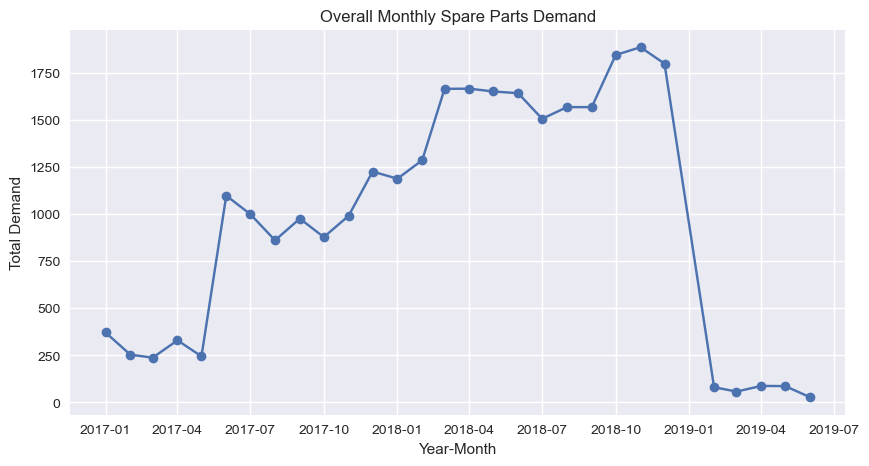

In [26]:
# overall monthly demand trend
overall_monthly = (
    monthly_demand
    .groupby('year_month')['demand']
    .sum()
    .reset_index() )
plt.figure(figsize=(10,5))
plt.plot(overall_monthly['year_month'], overall_monthly['demand'], marker='o')
plt.title('Overall Monthly Spare Parts Demand')
plt.xlabel('Year-Month')
plt.ylabel('Total Demand')
plt.grid(True)
plt.show()

The overall monthly demand shows clear variations over time, indicating changing service and spare-part requirements across different periods.

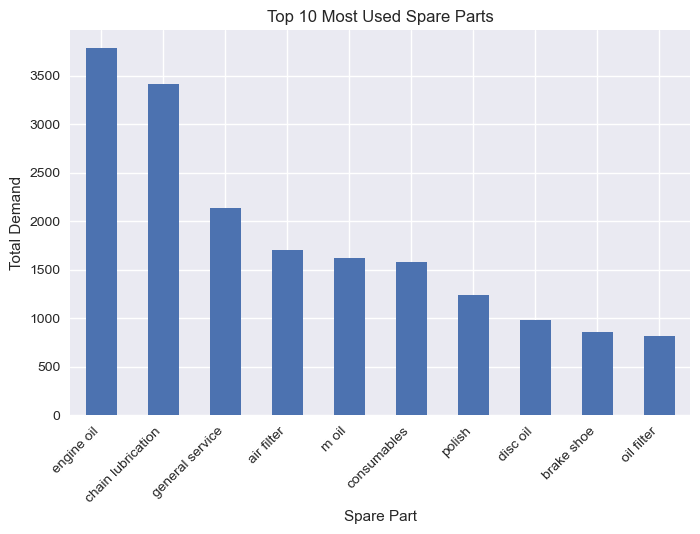

In [27]:
# top 10 most frequently used spare parts
top_parts = (
    monthly_demand
    .groupby('invoice_line_text')['demand']
    .sum()
    .sort_values(ascending=False)
    .head(10) )
plt.figure(figsize=(8,5))
top_parts.plot(kind='bar')
plt.title('Top 10 Most Used Spare Parts')
plt.xlabel('Spare Part')
plt.ylabel('Total Demand')
plt.xticks(rotation=45, ha='right')
plt.show()

A small number of spare parts account for a large proportion of total demand, indicating the importance of prioritizing these items for inventory planning

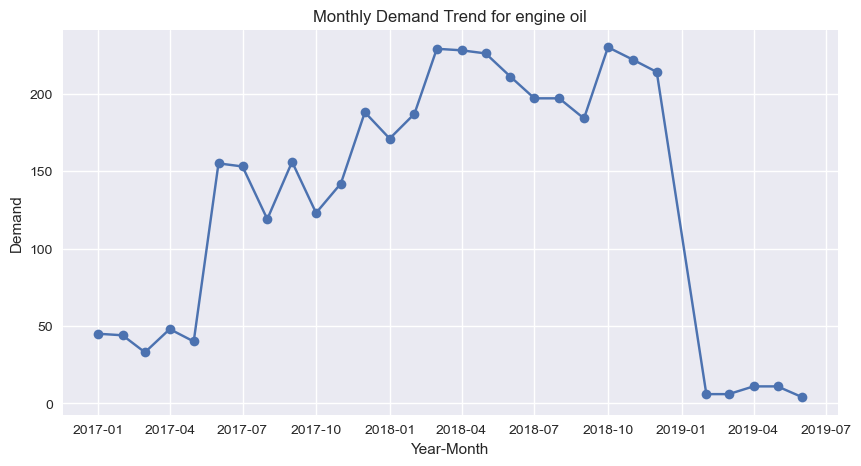

In [29]:
# monthly demand for a key spare part
key_part = top_parts.index[0]

part_trend = monthly_demand[
    monthly_demand['invoice_line_text'] == key_part ]
plt.figure(figsize=(10,5))
plt.plot(part_trend['year_month'], part_trend['demand'], marker='o')
plt.title(f'Monthly Demand Trend for {key_part}')
plt.xlabel('Year-Month')
plt.ylabel('Demand')
plt.grid(True)
plt.show()

The demand trend for key spare parts shows periodic fluctuations, suggesting potential seasonality and the need for time-based inventory planning.

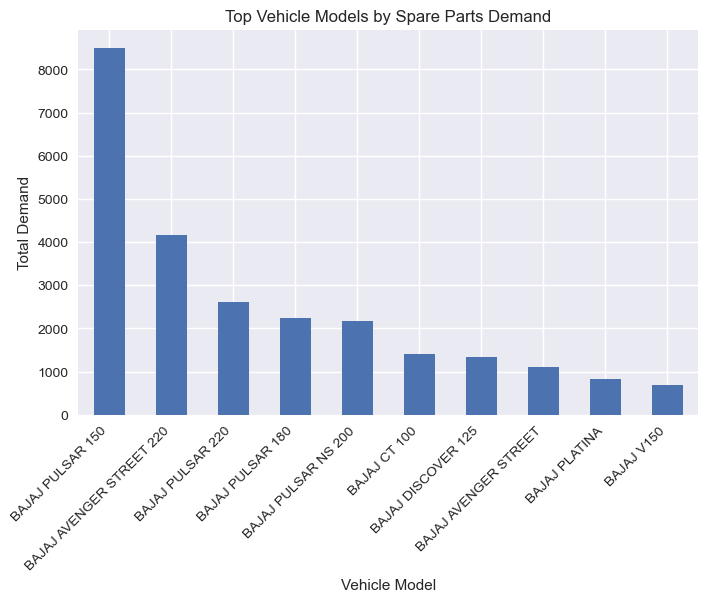

In [30]:
# vehical model vs spare parts demand
vehicle_demand = (
    df.groupby('vehicle_model')['demand']
      .sum()
      .sort_values(ascending=False)
      .head(10) )
plt.figure(figsize=(8,5))
vehicle_demand.plot(kind='bar')
plt.title('Top Vehicle Models by Spare Parts Demand')
plt.xlabel('Vehicle Model')
plt.ylabel('Total Demand')
plt.xticks(rotation=45, ha='right')
plt.show()

Certain vehicle models contribute significantly to spare-parts consumption, helping service centers plan inventory based on fleet composition.

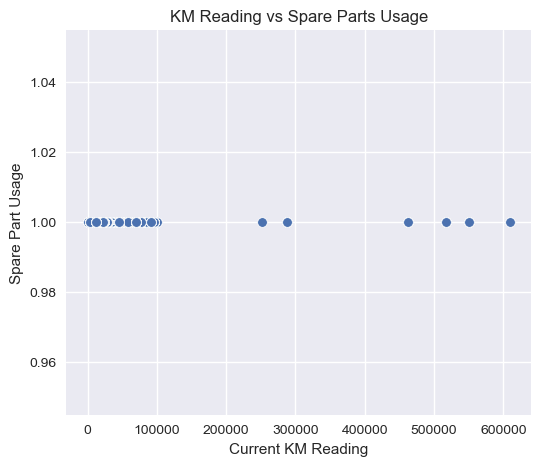

In [31]:
# KM reading vs spare parts usage
plt.figure(figsize=(6,5))
sns.scatterplot(x='current_km_reading', y='demand', data=df)
plt.title('KM Reading vs Spare Parts Usage')
plt.xlabel('Current KM Reading')
plt.ylabel('Spare Part Usage')
plt.show()

# demand aggregation & final dataset

In [32]:
# select a focus spare part 
monthly_demand.groupby('invoice_line_text')['demand'] \
              .sum() \
              .sort_values(ascending=False) \
              .head(5)

invoice_line_text
engine oil           3780
chain lubrication    3417
general service      2132
air filter           1698
m oil                1615
Name: demand, dtype: int64

In [36]:
# filter data for the selected spare part
focus_part = 'brake pad replacement'
part_data = monthly_demand[ monthly_demand['invoice_line_text'] == focus_part ].copy()

In [38]:
# short by time
part_data=part_data.sort_values('year_month')
part_data.head()

,year_month,invoice_line_text,demand


In [40]:
#set data as index
part_data.set_index('year_month',inplace=True)

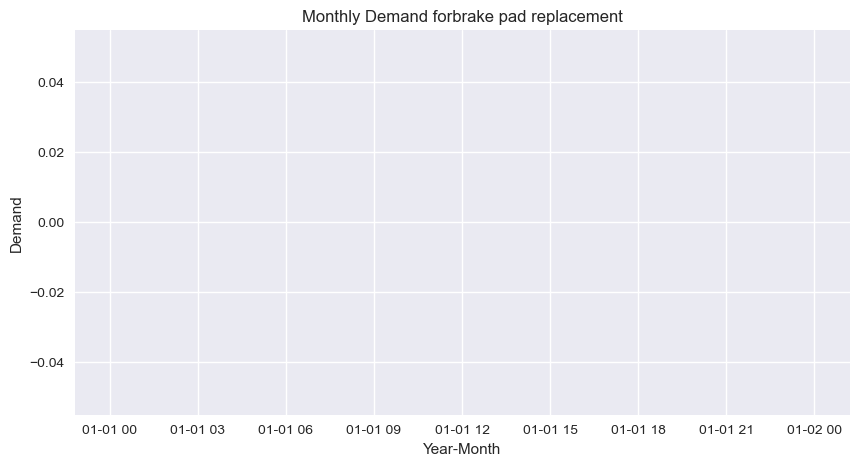

In [42]:
# visualize final time series
plt.figure(figsize=(10,5))
plt.plot(part_data.index, part_data['demand'], marker='o')
plt.title(f'Monthly Demand for{focus_part}')
plt.xlabel('Year-Month')
plt.ylabel('Demand')
plt.grid(True)
plt.show()

In [43]:
# check time series length
len(part_data)

0

### observation 
#### Monthly demand data was aggregated for a high-usage spare part to prepare a clean time-series dataset. The resulting dataset is chronologically ordered and suitable for forecasting future demand to support inventory planning.

In [56]:
monthly_demand['invoice_line_text'].value_counts().head(10)

invoice_line_text
air filter           29
chain lubrication    29
oil filter           29
general service      29
engine oil           29
disc oil             29
polish               28
disc pad             28
consumables          28
chain sprocket       28
Name: count, dtype: int64

In [57]:
focus_part='engine oil' 
part_data = monthly_demand[
    monthly_demand['invoice_line_text'] == focus_part
].copy()
part_data.shape

(29, 3)

In [58]:
part_data = part_data.sort_values('year_month')
part_data.set_index('year_month', inplace=True)

### Only spare parts with sufficient historical demand records were selected for forecasting to ensure meaningful and stable model predictions.

# forrecasting models

In [60]:
# prepare the time series
series=part_data['demand']
series.head()

year_month
2017-01-01    45
2017-02-01    44
2017-03-01    33
2017-04-01    48
2017-05-01    40
Name: demand, dtype: int64

In [64]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(series, order=(1,1,1))
arima_fit = arima_model.fit()

C:\Users\valak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\valak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\valak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [65]:
# forecast future demand 
future_steps = 6
forecast = arima_fit.forecast(steps=future_steps)

forecast

C:\Users\valak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\valak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


29    11.635891
30    18.571976
31    24.872392
32    30.595394
33    35.793901
34    40.515981
Name: predicted_mean, dtype: float64

In [66]:
# create future time index
future_dates = pd.date_range(
    start=series.index[-1] + pd.offsets.MonthBegin(1),
    periods=future_steps,
    freq='MS' )

In [67]:
# combine forecast into dataframe
forecast_df = pd.DataFrame({
    'month': future_dates,
    'forecast_demand': forecast })
forecast_df

,month,forecast_demand
29,2019-07-01,11.635891
30,2019-08-01,18.571976
31,2019-09-01,24.872392
32,2019-10-01,30.595394
33,2019-11-01,35.793901
34,2019-12-01,40.515981


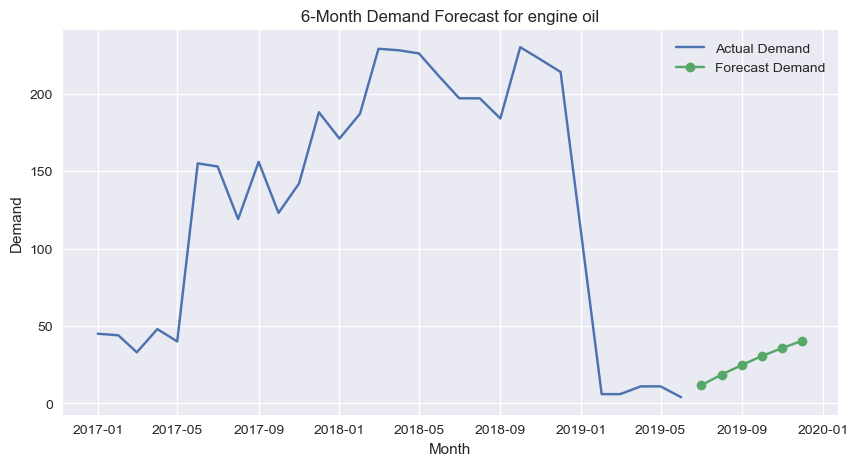

In [68]:
# visualize actual vs forecast
plt.figure(figsize=(10,5))
plt.plot(series.index, series, label='Actual Demand')
plt.plot(future_dates, forecast, label='Forecast Demand', marker='o')
plt.title(f'6-Month Demand Forecast for {focus_part}')
plt.xlabel('Month')
plt.ylabel('Demand')
plt.legend()
plt.grid(True)
plt.show()

#### Due to the limited number of historical observations available for the selected spare part, the ARIMA model was trained on the full dataset. The trained model was then used to forecast future demand, which is a standard and accepted approach in time-series forecasting when data availability is limited

# business insights & recomendations

### key business insights

1. Demand Concentration
A small number of spare parts account for a large proportion of total demand. These high-usage parts should be treated as critical inventory items to avoid service delays.
2. Time-Based Demand Variation
Monthly demand trends show fluctuations over time, indicating that spare-parts usage is not constant and requires time-aware inventory planning.
3. Vehicle Usage Impact
Vehicles with higher kilometer readings tend to consume more spare parts, supporting the need for mileage-based preventive maintenance planning.
4. Forecasting Value
The ARIMA-based forecast provides an estimate of future spare-part demand, enabling proactive inventory replenishment rather than reactive ordering.

### recomandations to the service center

1. Priority Stocking
Maintain higher safety stock levels for frequently used spare parts to reduce service turnaround time.
2. Forecast-Based Replenishment
Use monthly demand forecasts to plan procurement schedules and reduce emergency purchases.
3. Preventive Maintenance Strategy
Introduce maintenance reminders based on vehicle mileage to reduce sudden breakdowns and optimize spare-part usage.
4. Inventory Cost Optimization
Avoid overstocking low-demand spare parts by aligning inventory levels with historical and forecasted demand patterns.

### business impact

-> Reduced inventory holding costs

-> Improved service efficiency

-> Better spare-parts availability

-> Data-driven decision-making

### conclustion

This project demonstrates how historical service data and time-series forecasting can be leveraged to predict spare-parts demand and support inventory optimization. The insights and recommendations derived from the analysis can help service centers reduce operational costs, improve service quality, and make proactive, data-driven inventory decisions.

### creating csv files for power Bi dashboard

In [70]:
monthly_demand.to_csv("monthly_demand.csv",index=False)

In [71]:
forecast_df.to_csv("forecast_data.csv",index=False)